#Initial Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# prompt: generate the code to change the current working directory to main directory

import os

# Check the current working directory
print(os.getcwd())

# Change the current working directory
os.chdir('/content/drive/MyDrive/Complete Machine Learning') # Write the current working directory as parameter

# Check the current working directory
print(os.getcwd())

# List contents of the main directory (root directory)
!ls

/content
/content/drive/MyDrive/Complete Machine Learning
 Data		      'Gathering the Data'  'Open CV'
'Data Analysis'       'Machine learning'    'Python introduction.ipynb'
'Data Preprocessing'   Numpy.ipynb


In [3]:
Google_PS = pd.read_csv('Data/googleplaystore.csv')
sample = pd.read_csv('Data/Random_Data.csv')
AB_Data = pd.read_csv('Data/AB_NYC_2019.csv')
Scholarship = pd.read_csv('Data/scholarship.csv')

# Outlier
It is an observation in a given dataset that lies far from rest of the observations.  
>**for eg.** Measuring the body temperature, there was an entry of 998 degree Celsius.  
> it should have been 99.8 insted of 998.(Data entry error)

>**for eg.** Measuring the weight of high school students, there was an entry of 1234 which is higher unlikely.  

## Need ot fix Outlier
 We have to fix those **outlier error** before analysis, otherwise we get **bias** in our analysis.
> **for eg.** Consider a small dataset:  
> `sample= [15, 101, 18, 7, 13, 16, 11,21, 5, 15, 10, 9]`  
> This dataset have one **outlier** i.e. ***101***    

Due to **outlier** there is difference in **mean, median, Variance, Std**;

| | With outlier | | Without outlier |
| :--- | :--- | :--- | :--- |
|**Parimeter** | **Value** | **Parimeter** | **Value**|
| Mean | 20.08 | Mean | 12.72 |
| Median | 14.0  | Median | 13.0 |
| Mode | 15  | Mode | 15 |
| Variance | 614.74 | Variance | 21.28 |
| Std dev | 24.79  | Std dev | 4.61 |

## Why outliers are important
if we have to check error in credit card Transactions, Then we have to keep record of outlers.  
So keeping or notto keep outliers depend on problem statement.

## Hoe to treat outliers
1. Trimming (remove)
2. Capping (value < lower_range = lower_range & value > upper_limit = upper_limit.

## How to fix outliers
1. Z-score : (Normal distribution)
2. interquartile range (IQR) : (Skewed distributions)
3. Percentile (rest case)



/tmp/ipykernel_3004/2033377194.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(Scholarship['semester_percentage'])
/tmp/ipykernel_3004/2033377194.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(Scholarship['scholarship_exam_marks'])


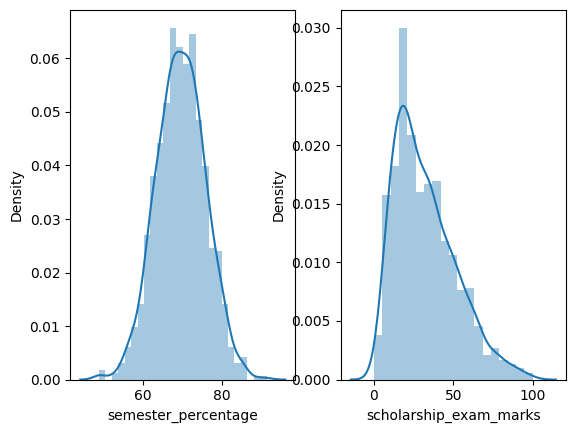

In [4]:
plt.subplot(1,2,1)
sns.distplot(Scholarship['semester_percentage'])
plt.subplot(1,2,2)
sns.distplot(Scholarship['scholarship_exam_marks'])
plt.show()

Therefor,  
Z-score in Semester_percentage  
IQR in Scholarship_exam_marks

# **Z-Score (Normal Distribution)**

Normal distribution is bell shaped curve where centre lies at the mean.  
* it is estimated that 68% of the data points lie between +/- 1 standard deviation.
* 95% of the data points lie *between* +/- 2 standard deviation
* 99.7% of the data points lie between +/- 3 standard deviation  
> The **values outside** the **3 standard deviation are outliers.**

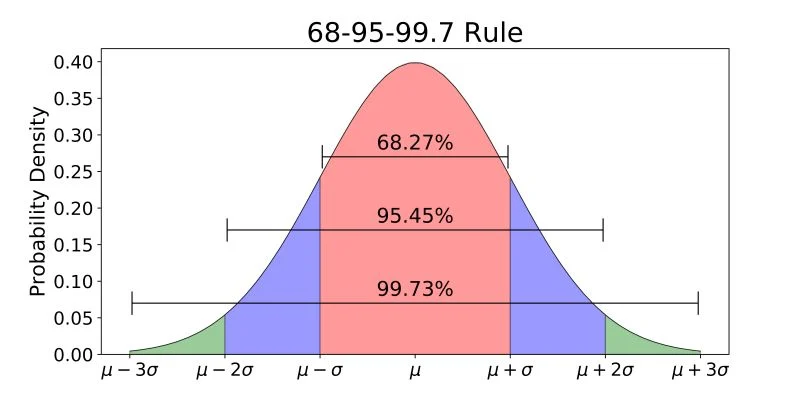

In [6]:
from IPython.display import Image, display
display(Image("Data Preprocessing/empirical-rule.png"))

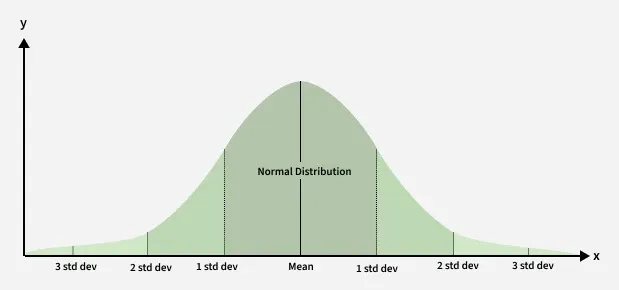

In [5]:
from IPython.display import Image, display
display(Image("Data Preprocessing/a_normal_distribution_3.png"))

/tmp/ipykernel_3004/1193960205.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(Scholarship['semester_percentage'])


<Axes: xlabel='semester_percentage', ylabel='Density'>

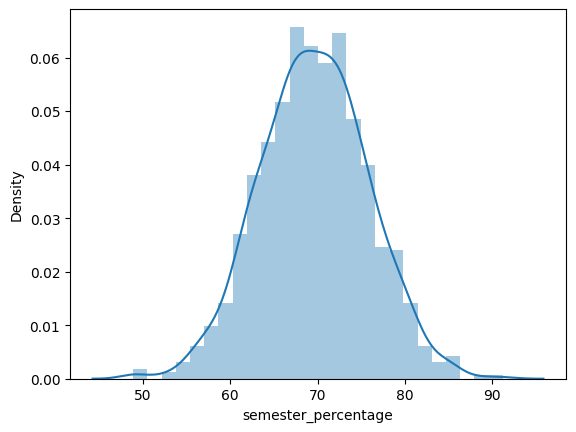

In [7]:
sns.distplot(Scholarship['semester_percentage'])

In [8]:
Scholarship.head()

,semester_percentage,scholarship_exam_marks,got_scholarship
0,71.9,26,1
1,74.6,38,1
2,75.4,40,1
3,64.2,8,1
4,72.3,17,0


In [9]:
Scholarship.shape

(1000, 3)

semester_percentage is in normal distribution so using z-score method

## Trimming

In [10]:
mean = Scholarship['semester_percentage'].mean()
std = Scholarship['semester_percentage'].std()

Upper = mean + 3*std
lower = mean - 3*std

display(mean, std)
display(Upper, lower)

np.float64(69.6124)

6.158978751323897

np.float64(88.08933625397168)

np.float64(51.13546374602831)

In [11]:
Scholarship[(Scholarship['semester_percentage'] < lower) | (Scholarship['semester_percentage'] > Upper)]

,semester_percentage,scholarship_exam_marks,got_scholarship
485,49.2,44,1
995,88.7,44,1
996,91.2,65,1
997,48.9,34,0
999,49.0,10,1


In [12]:
Scholarship[(Scholarship['semester_percentage'] > lower) & (Scholarship['semester_percentage'] < Upper)]

,semester_percentage,scholarship_exam_marks,got_scholarship
0,71.9,26,1
1,74.6,38,1
2,75.4,40,1
3,64.2,8,1
4,72.3,17,0
...,...,...,...
991,70.4,57,0
992,62.6,12,0
993,67.3,21,1
994,64.8,63,0


## Z Score

Normal distribution to standered normal **distribution**

In [13]:
Scholarship["Z_Score"] = (Scholarship['semester_percentage'] - mean) / std
Scholarship.head()

,semester_percentage,scholarship_exam_marks,got_scholarship,Z_Score
0,71.9,26,1,0.371425
1,74.6,38,1,0.809810
2,75.4,40,1,0.939701
3,64.2,8,1,-0.878782
4,72.3,17,0,0.436371


/tmp/ipykernel_3004/2450729602.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(Scholarship['semester_percentage'])
/tmp/ipykernel_3004/2450729602.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(Scholarship['Z_Score'])


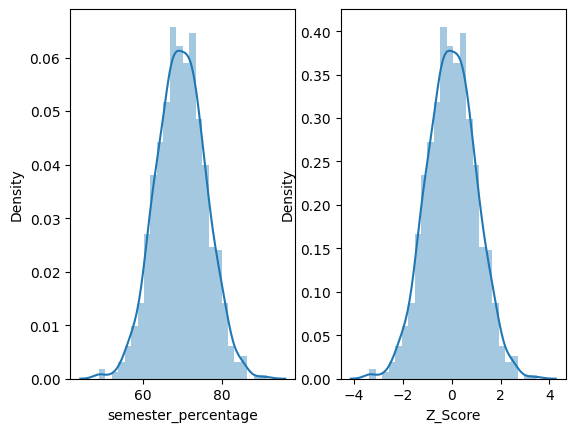

In [14]:
# To visualize no change in menaing of data
plt.subplot(1,2,1)
sns.distplot(Scholarship['semester_percentage'])
plt.subplot(1,2,2)
sns.distplot(Scholarship['Z_Score'])
plt.show()

In [15]:
Scholarship[(Scholarship['Z_Score'] < -3) | (Scholarship['Z_Score'] > 3)]

,semester_percentage,scholarship_exam_marks,got_scholarship,Z_Score
485,49.2,44,1,-3.314251
995,88.7,44,1,3.099150
996,91.2,65,1,3.505062
997,48.9,34,0,-3.362960
999,49.0,10,1,-3.346724


In [16]:
Scholarship[(Scholarship['Z_Score'] > -3) & (Scholarship['Z_Score'] < 3)]

,semester_percentage,scholarship_exam_marks,got_scholarship,Z_Score
0,71.9,26,1,0.371425
1,74.6,38,1,0.809810
2,75.4,40,1,0.939701
3,64.2,8,1,-0.878782
4,72.3,17,0,0.436371
...,...,...,...,...
991,70.4,57,0,0.127878
992,62.6,12,0,-1.138565
993,67.3,21,1,-0.375452
994,64.8,63,0,-0.781363


It might be the change that removing those outliers can affect the observation.  
so insted of removing those row we can apply capping.

## Capping
Value less then the lower limit replace it with lower limit.  
Value greater then upper limit replace it with upper limit.

In [17]:
Scholarship['semester_percentage'] = np.where(Scholarship['semester_percentage'] < lower, lower,
                                              np.where(Scholarship['semester_percentage'] > Upper, Upper,
                                                       Scholarship['semester_percentage']))

In [18]:
# No outlier exist
Scholarship[(Scholarship['semester_percentage'] < lower) | (Scholarship['semester_percentage'] > Upper)]

,semester_percentage,scholarship_exam_marks,got_scholarship,Z_Score


# **Interquartile range (IQR) : (Skewed distributions)**

## Quartiles :
Three points which divide the total data into four equal parts when it has been orderly arranged are known as Quartiles.

Q1 - first Quartile , Q2- second Quartile, Q3 - third Quartile

## IQR
The data range that contains the middle 50% of data `IQR = Q3 - Q1`

## Outlier range in IQR
***1.5 * IQR rule:*** The values which are below `Q1 - 1.5*IQR` or value above `Q3 + 1.5*OQR` are outlier.

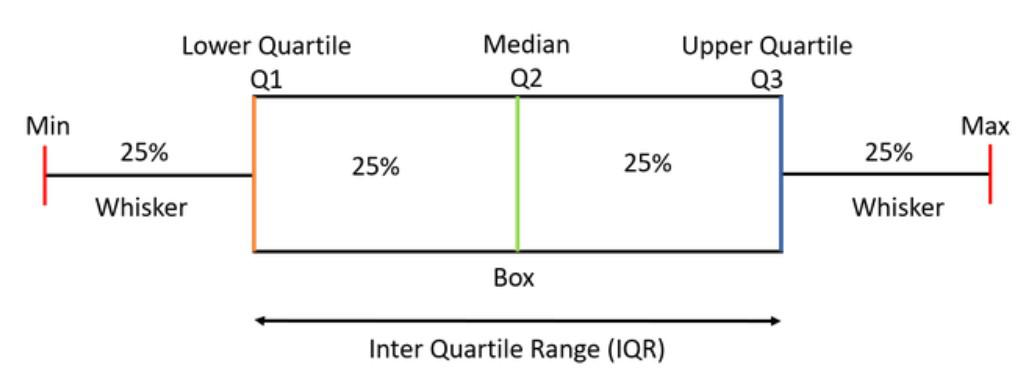

In [19]:
from IPython.display import Image, display
display(Image("Data Preprocessing/box.jpg"))

/tmp/ipykernel_3004/3852993232.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(Scholarship['scholarship_exam_marks'])


<Axes: xlabel='scholarship_exam_marks', ylabel='Density'>

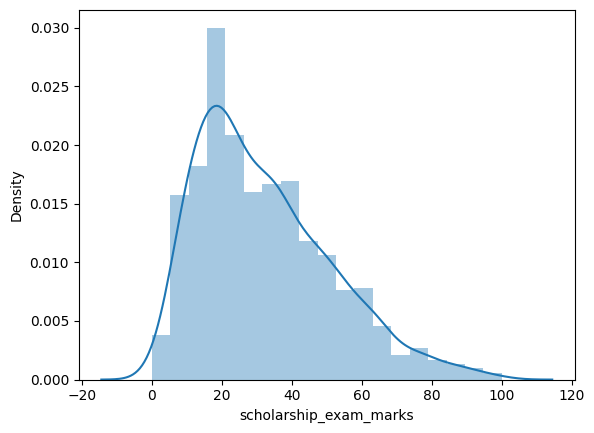

In [20]:
sns.distplot(Scholarship['scholarship_exam_marks'])

<Axes: ylabel='scholarship_exam_marks'>

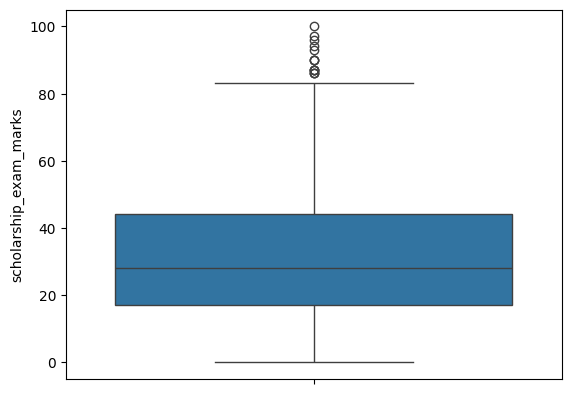

In [21]:
sns.boxplot(Scholarship['scholarship_exam_marks'])

## Trimming

In [22]:
Q1 = Scholarship['scholarship_exam_marks'].quantile(0.25)
Q3 = Scholarship['scholarship_exam_marks'].quantile(0.75)

In [23]:
IQR = Q3 - Q1
min_range = Q1 - 1.5*IQR
max_range = Q3 + 1.5*IQR

print("Q1: ",Q1)
print("Q3: ",Q3)
print("IQ#: ",IQR)
print("Min_range",min_range)
print("Max_range", max_range)

Q1:  17.0
Q3:  44.0
IQ#:  27.0
Min_range -23.5
Max_range 84.5


In [24]:
Scholarship['scholarship_exam_marks'].describe()

,scholarship_exam_marks
count,1000.000000
mean,32.225000
std,19.130822
min,0.000000
25%,17.000000
50%,28.000000
75%,44.000000
max,100.000000


In [25]:
Scholarship[(Scholarship['scholarship_exam_marks'] < min_range) | (Scholarship['scholarship_exam_marks'] > max_range)]

,semester_percentage,scholarship_exam_marks,got_scholarship,Z_Score
9,77.5,94,1,1.280667
40,66.0,86,1,-0.586526
61,75.1,86,0,0.890992
134,63.3,93,0,-1.024910
162,78.0,90,0,1.361849
283,70.9,87,0,0.209061
290,83.8,87,0,2.303564
311,69.7,87,1,0.014223
324,66.4,90,0,-0.521580
630,65.6,96,1,-0.651472


In [26]:
New_data = Scholarship[(Scholarship['scholarship_exam_marks'] > min_range) & (Scholarship['scholarship_exam_marks'] < max_range)]

/tmp/ipykernel_3004/486671791.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns. distplot(Scholarship["scholarship_exam_marks"])
/tmp/ipykernel_3004/486671791.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(New_data["scholarship_exam_marks"])


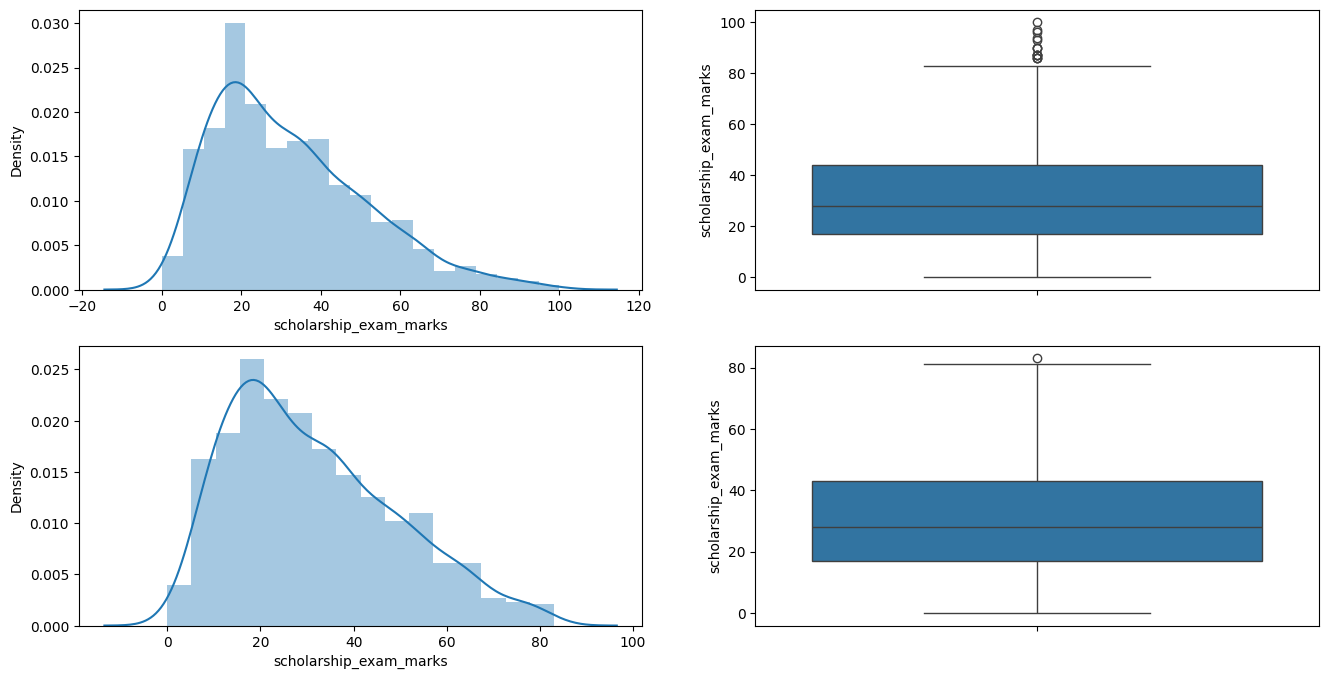

In [27]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns. distplot(Scholarship["scholarship_exam_marks"])

plt.subplot(2,2,2)
sns .boxplot(Scholarship["scholarship_exam_marks"])

plt.subplot(2,2,3)
sns.distplot(New_data["scholarship_exam_marks"])

plt.subplot(2,2,4)
sns.boxplot(New_data["scholarship_exam_marks"])

plt.show()

## Capping

In [28]:
from numpy._core.multiarray import where
Scholarship['scholarship_exam_marks'] = np.where(Scholarship['scholarship_exam_marks']>max_range, max_range,
                                                 np.where(Scholarship['scholarship_exam_marks']<min_range, min_range, Scholarship['scholarship_exam_marks'])
                                                 )

In [29]:
Scholarship.shape

(1000, 4)

<Axes: ylabel='scholarship_exam_marks'>

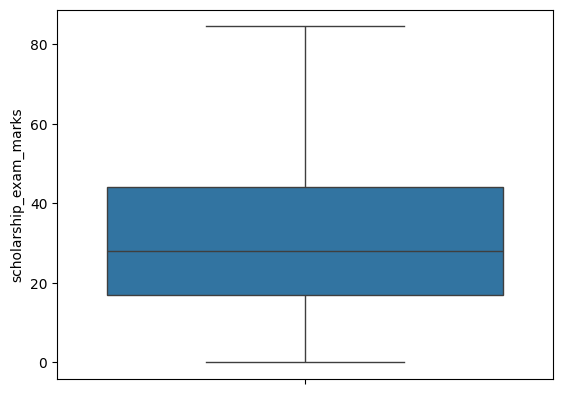

In [30]:
sns.boxplot(Scholarship['scholarship_exam_marks'])

# Percentile
The percentile is a statistical measure that gives the percentage of data values that fall below a given data value


## How to check for outlier?
Decide percentile on both sides which you consider as outlier

In [32]:
WH_Data = pd.read_csv("Data/weight-height.csv")

In [33]:
WH_Data.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


/tmp/ipykernel_3004/2245208452.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(WH_Data['Height'])


<Axes: xlabel='Height', ylabel='Density'>

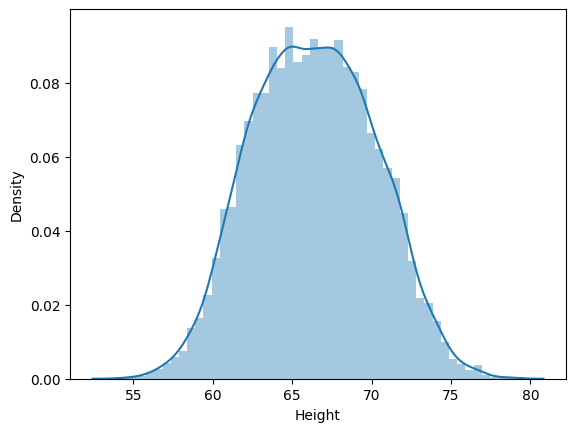

In [35]:
sns.distplot(WH_Data['Height'])

<Axes: ylabel='Height'>

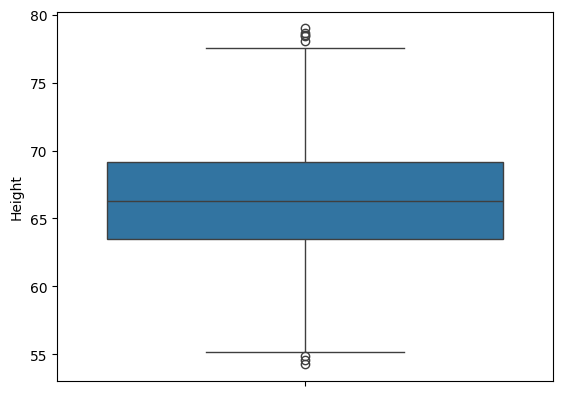

In [37]:
sns.boxplot(WH_Data['Height'])

In [34]:
WH_Data.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.367560,161.440357
std,3.847528,32.108439
min,54.263133,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,78.998742,269.989699


## Trimming

In [48]:
min_limit = WH_Data['Height'].quantile(0.01)
max_limit = WH_Data['Height'].quantile(0.99)

min_limit, max_limit

(np.float64(58.13441158671655), np.float64(74.7857900583366))

In [49]:
WH_Data[(WH_Data['Height']<min_limit) | (WH_Data['Height']>max_limit)]

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9761,Female,56.975279,90.341784
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957
9904,Female,57.028857,101.202551


In [50]:
WH_Data[(WH_Data['Height']>min_limit) & (WH_Data['Height']<max_limit)]

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


## Capping

In [51]:
WH_Data['Height'] = np.where(WH_Data['Height']<min_limit, min_limit,
                          np.where(WH_Data['Height']>max_limit, max_limit, WH_Data['Height']))